<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/U2Net/u2netcorposdagua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#bloco 1

import torch
import os
import sys
from google.colab import drive

#gpu
torch.cuda.is_available()

drive.mount('/content/drive')

caminho_dataset = "/content/drive/MyDrive/waterbodiesdataset.zip"

os.path.exists(caminho_dataset)

!pip install -q opencv-python pillow scikit-image matplotlib gdown

!git clone https://github.com/xuebinqin/U-2-Net.git

!mkdir -p /content/U-2-Net/data/waterbody/images
!mkdir -p /content/U-2-Net/data/waterbody/masks
!mkdir -p /content/U-2-Net/saved_models/u2net
!mkdir -p /content/U-2-Net/val_output

Mounted at /content/drive
Cloning into 'U-2-Net'...
remote: Enumerating objects: 1077, done.
remote: Counting objects: 100% (422/422), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 1077 (delta 398), reused 380 (delta 380), pack-reused 655 (from 2)
Receiving objects: 100% (1077/1077), 66.95 MiB | 36.72 MiB/s, done.
Resolving deltas: 100% (539/539), done.


In [ ]:
#quantas imagens tem no data set
import glob

imagens = glob.glob('/content/U-2-Net/data/waterbody/images/*')
print(f"total de imagens: {len(imagens)}")

total de imagens: 0


In [ ]:
#bloco 2
#extrair e organizar as imagens e mascaras

import zipfile
import os
import shutil
from glob import glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

caminho_dataset = "/content/drive/MyDrive/waterbodiesdataset.zip"
pasta_temp = "/content/temp_extraido"
pasta_destino = "/content/U-2-Net/data/waterbody"

with zipfile.ZipFile(caminho_dataset, 'r') as zip_ref:

    zip_ref.extractall(pasta_temp)

# procura as pastas de imagem e mascara
pastas = os.listdir(pasta_temp)

#pegar as pastas
pasta_imagens = None
pasta_mascaras = None

for pasta in pastas:
    caminho_pasta = os.path.join(pasta_temp, pasta)
    if os.path.isdir(caminho_pasta):
        nome_pasta = pasta.lower()
        if 'image' in nome_pasta or 'img' in nome_pasta:
            pasta_imagens = caminho_pasta
        elif 'mask' in nome_pasta or 'gt' in nome_pasta or 'label' in nome_pasta:
            pasta_mascaras = caminho_pasta

#subpastas
if pasta_imagens is None or pasta_mascaras is None:
    for pasta in pastas:
        caminho_pasta = os.path.join(pasta_temp, pasta)
        if os.path.isdir(caminho_pasta):
            subpastas = os.listdir(caminho_pasta)
            for sub in subpastas:
                caminho_sub = os.path.join(caminho_pasta, sub)
                if os.path.isdir(caminho_sub):
                    nome_sub = sub.lower()
                    if 'image' in nome_sub or 'img' in nome_sub:
                        pasta_imagens = caminho_sub
                    elif 'mask' in nome_sub or 'gt' in nome_sub or 'label' in nome_sub:
                        pasta_mascaras = caminho_sub

#imagens tao na raiz e mascaras
if pasta_imagens is None:
    pasta_imagens = pasta_temp
if pasta_mascaras is None:
    pasta_mascaras = pasta_temp

imagens = []
extensoes_validas = ('.jpg', '.jpeg', '.png', '.tif', '.bmp')
for arquivo in os.listdir(pasta_imagens):
    if arquivo.lower().endswith(extensoes_validas):
        imagens.append(os.path.join(pasta_imagens, arquivo))

mascaras = []
for arquivo in os.listdir(pasta_mascaras):
    if arquivo.lower().endswith(extensoes_validas):
        mascaras.append(os.path.join(pasta_mascaras, arquivo))

#pastas de destino
os.makedirs(f"{pasta_destino}/images", exist_ok=True)
os.makedirs(f"{pasta_destino}/masks", exist_ok=True)

nomes_imagens = {os.path.splitext(os.path.basename(img))[0]: img for img in imagens}
nomes_mascaras = {os.path.splitext(os.path.basename(mask))[0]: mask for mask in mascaras}

nomes_comuns = set(nomes_imagens.keys()) & set(nomes_mascaras.keys())

for nome in nomes_comuns:
    #copia imagem
    shutil.copy2(nomes_imagens[nome], f"{pasta_destino}/images/{nome}.png")
    #copia mascara
    mascara_origem = nomes_mascaras[nome]
    mascara = cv2.imread(mascara_origem, cv2.IMREAD_GRAYSCALE)
    if mascara is not None:
        #mascara seja binaria (0 e 255)
        if mascara.max() > 1:
            mascara = (mascara > 127).astype(np.uint8) * 255
        cv2.imwrite(f"{pasta_destino}/masks/{nome}.png", mascara)

#listas finais
imagens_final = sorted(glob(f"{pasta_destino}/images/*"))
mascaras_final = sorted(glob(f"{pasta_destino}/masks/*"))

#treino e teste
img_train, img_val, mask_train, mask_val = train_test_split(
    imagens_final, mascaras_final, test_size=0.2, random_state=42
)

#arquivos de lista que a u2net usa
with open(f"{pasta_destino}/train.txt", 'w') as f:
    for img in img_train:
        nome = os.path.basename(img)
        nome_sem_ext = os.path.splitext(nome)[0]
        f.write(f"{nome_sem_ext}\n")

with open(f"{pasta_destino}/val.txt", 'w') as f:
    for img in img_val:
        nome = os.path.basename(img)
        nome_sem_ext = os.path.splitext(nome)[0]
        f.write(f"{nome_sem_ext}\n")

shutil.rmtree(pasta_temp)

In [ ]:
#bloco 3

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
from glob import glob

os.chdir('/content/U-2-Net')
sys.path.append('/content/U-2-Net')

from model import U2NET, U2NETP

#classe pra carregar dataset
class WaterDataset(Dataset):
    def __init__(self, lista_arquivos, pasta_imagens, pasta_mascaras, tamanho=320):
        self.tamanho = tamanho
        self.pasta_imagens = pasta_imagens
        self.pasta_mascaras = pasta_mascaras

        #lista de arquivos
        with open(lista_arquivos, 'r') as f:
            self.arquivos = [linha.strip() for linha in f.readlines()]

    def __len__(self):
        return len(self.arquivos)

    def __getitem__(self, idx):
        nome = self.arquivos[idx]

        img_path = os.path.join(self.pasta_imagens, f"{nome}.png")
        imagem = cv2.imread(img_path)
        imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
        imagem = cv2.resize(imagem, (self.tamanho, self.tamanho))
        imagem = imagem.astype(np.float32) / 255.0
        imagem = imagem.transpose((2, 0, 1))  #hwc > chw

        mask_path = os.path.join(self.pasta_mascaras, f"{nome}.png")
        mascara = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mascara = cv2.resize(mascara, (self.tamanho, self.tamanho), interpolation=cv2.INTER_NEAREST)
        mascara = mascara.astype(np.float32) / 255.0
        mascara = mascara[np.newaxis, :, :]  #adiciona canal

        return torch.from_numpy(imagem), torch.from_numpy(mascara)

#calcular acuracia e iou
def calcular_metricas(pred, target):
    #pred e target sao tensores
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    #achata tudo pra 1d
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    #acuracia
    acertos = (pred_flat == target_flat).sum().item()
    total = target_flat.numel()
    acuracia = acertos / total

    #iou
    intersecao = (pred_flat * target_flat).sum().item()
    uniao = ((pred_flat + target_flat) > 0).sum().item()

    if uniao == 0:
        iou = 1.0  #considera 1
    else:
        iou = intersecao / uniao

    return acuracia, iou

dataset_treino = WaterDataset(
    '/content/U-2-Net/data/waterbody/train.txt',
    '/content/U-2-Net/data/waterbody/images',
    '/content/U-2-Net/data/waterbody/masks'
)

dataset_val = WaterDataset(
    '/content/U-2-Net/data/waterbody/val.txt',
    '/content/U-2-Net/data/waterbody/images',
    '/content/U-2-Net/data/waterbody/masks'
)

#dataloaders
loader_treino = DataLoader(dataset_treino, batch_size=8, shuffle=True, num_workers=2)
loader_val = DataLoader(dataset_val, batch_size=8, shuffle=False, num_workers=2)

modelo = U2NET(3, 1)  #3 canais de entrada (rgb), 1 saida (binaria)
modelo = modelo.cuda() if torch.cuda.is_available() else modelo

otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)
criterio = nn.BCEWithLogitsLoss()

print("tudo pronto pra começar o treinamento")

tudo pronto pra começar o treinamento


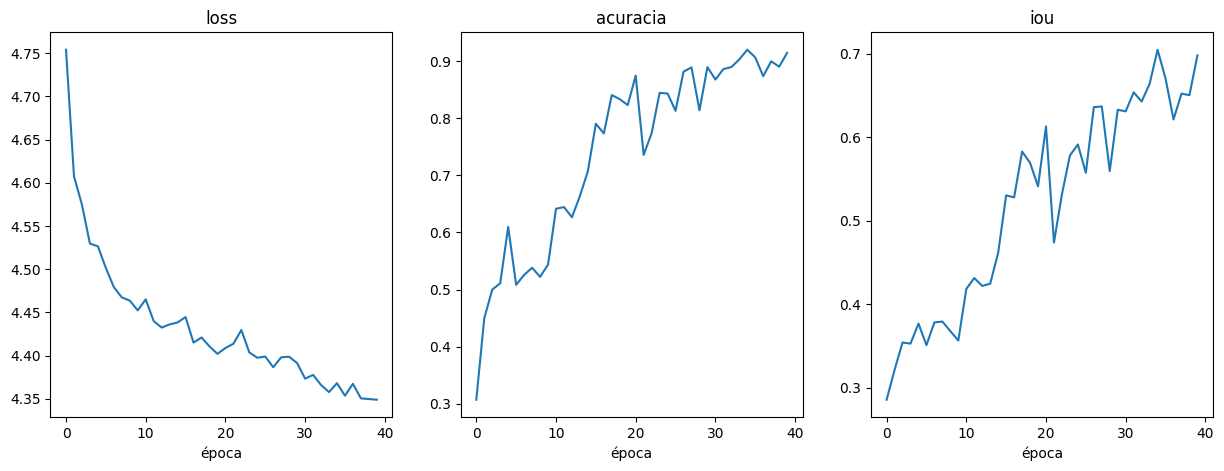

época 40/40
loss: 4.3490
acuracia: 0.9144
iou: 0.6982
melhor iou: 0.7048
tempo por época: 2.31 minutos
tempo restante: 0.0 horas


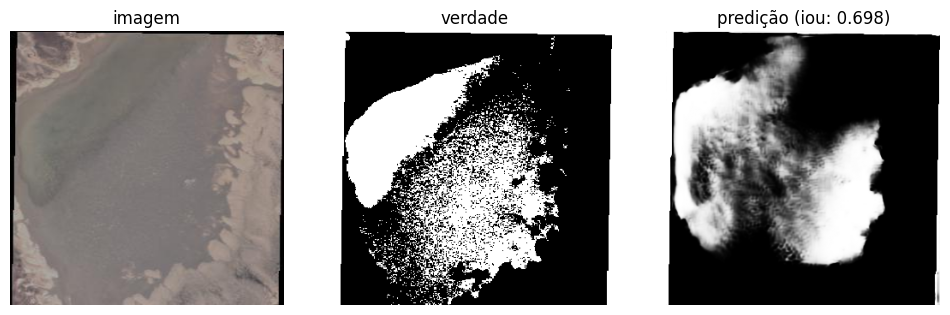


treinamento finalizado!
melhor iou alcançado: 0.7048
modelo salvo em: /content/U-2-Net/saved_models/u2net/waterbody.pth


In [ ]:
#bloco 4
#adaptado pra 2841 imagens

import time
import numpy as np
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from IPython.display import clear_output

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"treinando em: {dispositivo}")

#configurações otimizadas
num_epocas = 40  #reduzi de 100 pra 40
melhor_iou = 0
caminho_salvar = '/content/U-2-Net/saved_models/u2net/waterbody.pth'
modelo = modelo.to(dispositivo)

#mixed precision pra acelerar
scaler = GradScaler()

#aumenta batch size
try:
    loader_treino = DataLoader(dataset_treino, batch_size=12, shuffle=True, num_workers=2, pin_memory=True)
    loader_val = DataLoader(dataset_val, batch_size=12, shuffle=False, num_workers=2, pin_memory=True)
except:
    loader_treino = DataLoader(dataset_treino, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
    loader_val = DataLoader(dataset_val, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

historico_loss = []
historico_acuracia = []
historico_iou = []

print(f"começando treinamento - {len(dataset_treino)} imagens pra treino, {len(dataset_val)} pra validação")
print(f"batch size: {loader_treino.batch_size}, épocas: {num_epocas}")

for epoca in range(num_epocas):
    inicio = time.time()

    modelo.train()
    loss_total = 0

    for imagens, mascaras in loader_treino:
        imagens = imagens.to(dispositivo, non_blocking=True)
        mascaras = mascaras.to(dispositivo, non_blocking=True)

        otimizador.zero_grad()

        with autocast():
            outputs = modelo(imagens)
            loss = 0
            for saida in outputs:
                loss += criterio(saida, mascaras)

        scaler.scale(loss).backward()
        scaler.step(otimizador)
        scaler.update()

        loss_total += loss.item()

    loss_media = loss_total / len(loader_treino)
    historico_loss.append(loss_media)


    modelo.eval()
    acuracia_total = 0
    iou_total = 0

    #valida em 20% do dataset pra acelerar
    subset_val = torch.utils.data.Subset(dataset_val, range(0, len(dataset_val), 5))
    loader_subset = DataLoader(subset_val, batch_size=8, shuffle=False, num_workers=2)

    with torch.no_grad():
        for imagens, mascaras in loader_subset:
            imagens = imagens.to(dispositivo)
            mascaras = mascaras.to(dispositivo)

            outputs = modelo(imagens)
            saida_final = outputs[0]
            pred = torch.sigmoid(saida_final)

            for i in range(pred.shape[0]):
                acuracia, iou = calcular_metricas(pred[i], mascaras[i])
                acuracia_total += acuracia
                iou_total += iou

    acuracia_media = acuracia_total / len(subset_val)
    iou_medio = iou_total / len(subset_val)

    historico_acuracia.append(acuracia_media)
    historico_iou.append(iou_medio)


    if iou_medio > melhor_iou:
        melhor_iou = iou_medio
        torch.save(modelo.state_dict(), caminho_salvar)


    fim = time.time()
    tempo_epoca = (fim - inicio) / 60  #em minutos

    if (epoca + 1) % 5 == 0:
        clear_output(wait=True)

        #graficos
        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.plot(historico_loss)
        plt.title('loss')
        plt.xlabel('época')

        plt.subplot(1,3,2)
        plt.plot(historico_acuracia)
        plt.title('acuracia')
        plt.xlabel('época')

        plt.subplot(1,3,3)
        plt.plot(historico_iou)
        plt.title('iou')
        plt.xlabel('época')

        plt.show()

        #tempo restante
        epocas_restantes = num_epocas - (epoca + 1)
        minutos_restantes = tempo_epoca * epocas_restantes
        horas_restantes = minutos_restantes / 60

        print(f"época {epoca+1}/{num_epocas}")
        print(f"loss: {loss_media:.4f}")
        print(f"acuracia: {acuracia_media:.4f}")
        print(f"iou: {iou_medio:.4f}")
        print(f"melhor iou: {melhor_iou:.4f}")
        print(f"tempo por época: {tempo_epoca:.2f} minutos")
        print(f"tempo restante: {horas_restantes:.1f} horas")

        #exemplo
        modelo.eval()
        with torch.no_grad():
            idx = np.random.randint(len(dataset_val))
            img, mask = dataset_val[idx]
            img_batch = img.unsqueeze(0).to(dispositivo)
            saida = modelo(img_batch)
            pred = torch.sigmoid(saida[0]).cpu().numpy()[0,0]

            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.imshow(img.permute(1,2,0).numpy())
            plt.title('imagem')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.imshow(mask[0].numpy(), cmap='gray')
            plt.title('verdade')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.imshow(pred, cmap='gray')
            plt.title(f'predição (iou: {iou_medio:.3f})')
            plt.axis('off')

            plt.show()

    else:
        print(f"época {epoca+1} concluída - iou: {iou_medio:.4f} - tempo: {tempo_epoca:.2f}min")

print("\n" + "="*40)
print("treinamento finalizado!")
print(f"melhor iou alcançado: {melhor_iou:.4f}")
print(f"modelo salvo em: {caminho_salvar}")

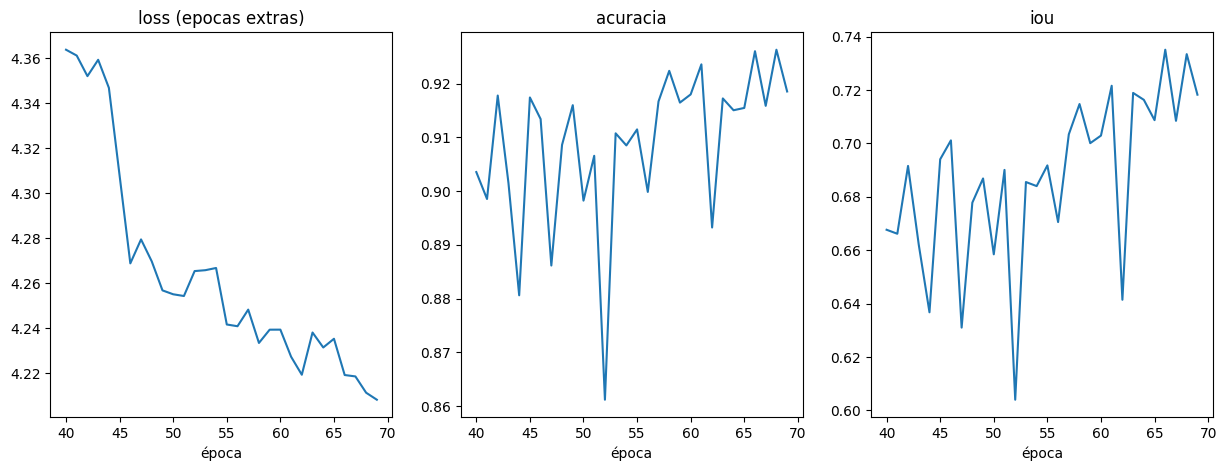

época 70/70
loss: 4.2082
acuracia: 0.9186
iou: 0.7182
melhor iou: 0.7351
tempo por época: 2.31 minutos


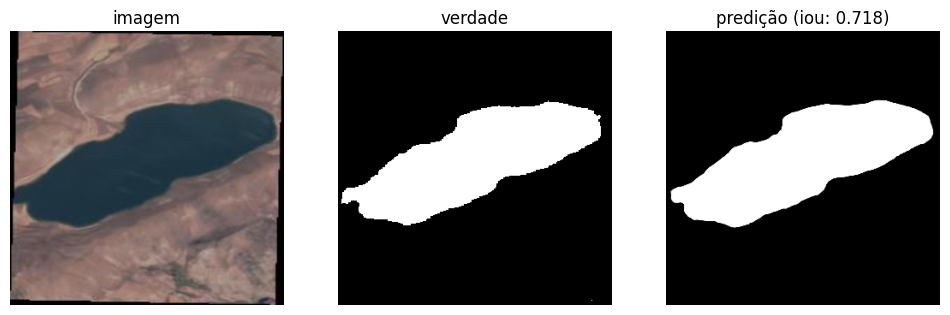


treinamento extra finalizado!
melhor iou melhorou de 0.6841 para 0.7351
modelo atualizado em: /content/U-2-Net/saved_models/u2net/waterbody.pth


In [ ]:
#bloco 5

import time
import numpy as np
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from IPython.display import clear_output

caminho_melhor_modelo = '/content/U-2-Net/saved_models/u2net/waterbody.pth'
modelo.load_state_dict(torch.load(caminho_melhor_modelo))
print("modelo carregado com sucesso!")

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(dispositivo)

epocas_iniciais = 40
epocas_extras = 30
num_epocas = epocas_iniciais + epocas_extras
melhor_iou = 0.6841

#recria os loaders com batch otimizado
try:
    loader_treino = DataLoader(dataset_treino, batch_size=12, shuffle=True, num_workers=2, pin_memory=True)
    loader_val = DataLoader(dataset_val, batch_size=12, shuffle=False, num_workers=2, pin_memory=True)
except:
    loader_treino = DataLoader(dataset_treino, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
    loader_val = DataLoader(dataset_val, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

#mixed precision
scaler = GradScaler()

historico_loss = []
historico_acuracia = []
historico_iou = []

print(f"continuando treinamento por mais {epocas_extras} epocas")
print(f"melhor iou ate agora: {melhor_iou:.4f}")

for epoca in range(epocas_iniciais, num_epocas):
    inicio = time.time()

    modelo.train()
    loss_total = 0

    for imagens, mascaras in loader_treino:
        imagens = imagens.to(dispositivo, non_blocking=True)
        mascaras = mascaras.to(dispositivo, non_blocking=True)

        otimizador.zero_grad()

        with autocast():
            outputs = modelo(imagens)
            loss = 0
            for saida in outputs:
                loss += criterio(saida, mascaras)

        scaler.scale(loss).backward()
        scaler.step(otimizador)
        scaler.update()

        loss_total += loss.item()

    loss_media = loss_total / len(loader_treino)
    historico_loss.append(loss_media)

    modelo.eval()
    acuracia_total = 0
    iou_total = 0

    subset_val = torch.utils.data.Subset(dataset_val, range(0, len(dataset_val), 5))
    loader_subset = DataLoader(subset_val, batch_size=8, shuffle=False, num_workers=2)

    with torch.no_grad():
        for imagens, mascaras in loader_subset:
            imagens = imagens.to(dispositivo)
            mascaras = mascaras.to(dispositivo)

            outputs = modelo(imagens)
            saida_final = outputs[0]
            pred = torch.sigmoid(saida_final)

            for i in range(pred.shape[0]):
                acuracia, iou = calcular_metricas(pred[i], mascaras[i])
                acuracia_total += acuracia
                iou_total += iou

    acuracia_media = acuracia_total / len(subset_val)
    iou_medio = iou_total / len(subset_val)

    historico_acuracia.append(acuracia_media)
    historico_iou.append(iou_medio)

    #salva
    if iou_medio > melhor_iou:
        melhor_iou = iou_medio
        torch.save(modelo.state_dict(), caminho_melhor_modelo)

    #mostra progresso
    fim = time.time()
    tempo_epoca = (fim - inicio) / 60

    if (epoca + 1) % 5 == 0 or epoca == num_epocas - 1:
        clear_output(wait=True)

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.plot(range(epocas_iniciais, epoca+1), historico_loss)
        plt.title('loss (epocas extras)')
        plt.xlabel('época')

        plt.subplot(1,3,2)
        plt.plot(range(epocas_iniciais, epoca+1), historico_acuracia)
        plt.title('acuracia')
        plt.xlabel('época')

        plt.subplot(1,3,3)
        plt.plot(range(epocas_iniciais, epoca+1), historico_iou)
        plt.title('iou')
        plt.xlabel('época')

        plt.show()

        epocas_restantes = num_epocas - (epoca + 1)
        minutos_restantes = tempo_epoca * epocas_restantes

        print(f"época {epoca+1}/{num_epocas}")
        print(f"loss: {loss_media:.4f}")
        print(f"acuracia: {acuracia_media:.4f}")
        print(f"iou: {iou_medio:.4f}")
        print(f"melhor iou: {melhor_iou:.4f}")
        print(f"tempo por época: {tempo_epoca:.2f} minutos")
        if epocas_restantes > 0:
            print(f"tempo restante: {minutos_restantes:.1f} minutos")

        #mostra exemplo
        modelo.eval()
        with torch.no_grad():
            idx = np.random.randint(len(dataset_val))
            img, mask = dataset_val[idx]
            img_batch = img.unsqueeze(0).to(dispositivo)
            saida = modelo(img_batch)
            pred = torch.sigmoid(saida[0]).cpu().numpy()[0,0]

            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.imshow(img.permute(1,2,0).numpy())
            plt.title('imagem')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.imshow(mask[0].numpy(), cmap='gray')
            plt.title('verdade')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.imshow(pred, cmap='gray')
            plt.title(f'predição (iou: {iou_medio:.3f})')
            plt.axis('off')

            plt.show()

    else:
        print(f"época {epoca+1} concluída - iou: {iou_medio:.4f} - tempo: {tempo_epoca:.2f}min")

print("\n" + "="*40)
print(f"treinamento extra finalizado!")
print(f"melhor iou melhorou de 0.6841 para {melhor_iou:.4f}")
print(f"modelo atualizado em: {caminho_melhor_modelo}")

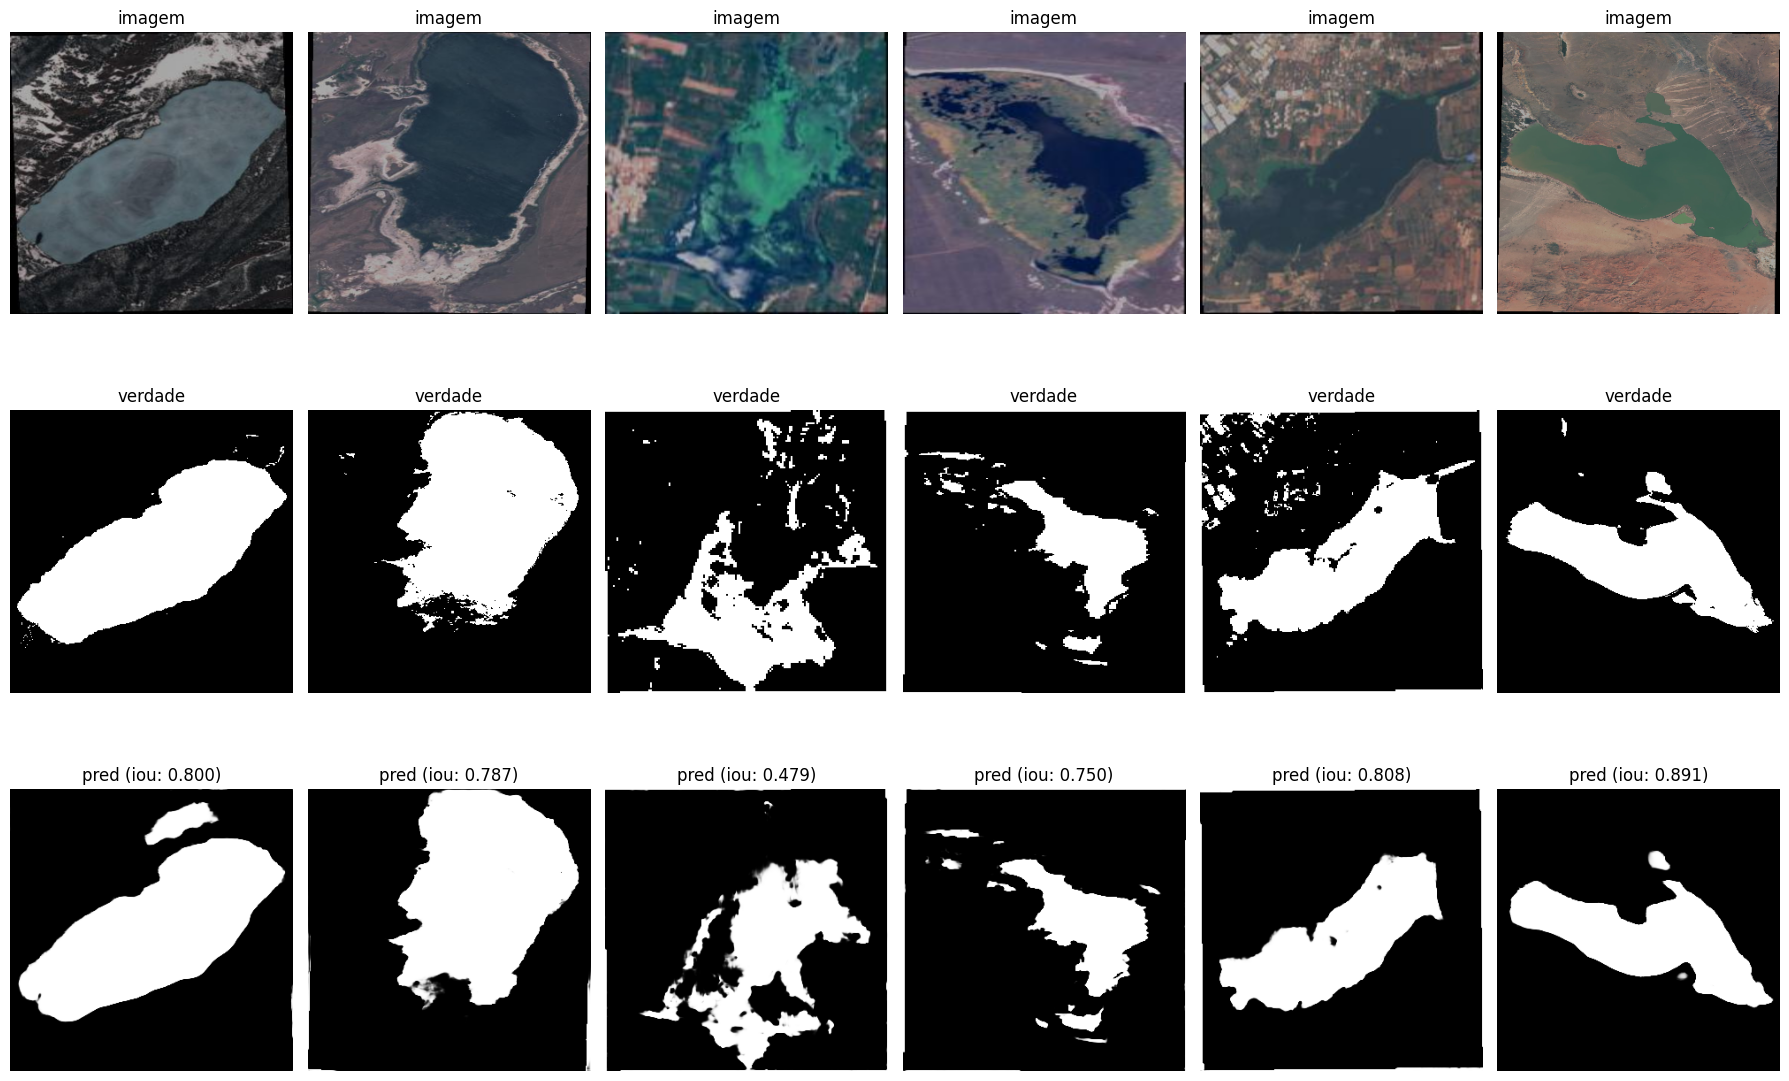

iou medio final: 0.7089


In [ ]:
#bloco 6
import random
import matplotlib.pyplot as plt

#carrega o modelo final
modelo.load_state_dict(torch.load('/content/U-2-Net/saved_models/u2net/waterbody.pth'))
modelo.eval()

indices = random.sample(range(len(dataset_val)), 6)

plt.figure(figsize=(18, 12))

for i, idx in enumerate(indices):
    img, mask = dataset_val[idx]

    with torch.no_grad():
        img_batch = img.unsqueeze(0).to(dispositivo)
        saida = modelo(img_batch)
        pred = torch.sigmoid(saida[0]).cpu().numpy()[0,0]
        pred_bin = (pred > 0.5).astype(float)

    #iou dessa imagem
    acuracia, iou_img = calcular_metricas(torch.from_numpy(pred_bin).unsqueeze(0).unsqueeze(0),
                                          torch.from_numpy(mask.numpy()))

    plt.subplot(3, 6, i+1)
    plt.imshow(img.permute(1,2,0).numpy())
    plt.title('imagem')
    plt.axis('off')

    plt.subplot(3, 6, i+7)
    plt.imshow(mask[0].numpy(), cmap='gray')
    plt.title('verdade')
    plt.axis('off')

    plt.subplot(3, 6, i+13)
    plt.imshow(pred, cmap='gray')
    plt.title(f'pred (iou: {iou_img:.3f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"iou medio final: 0.7089")

In [ ]:
#bloco 7
import shutil

caminho_drive = "/content/drive/MyDrive/modelo_agua_u2net.pth"
shutil.copy('/content/U-2-Net/saved_models/u2net/waterbody.pth', caminho_drive)

print(f"modelo salvo no drive: {caminho_drive}")

modelo salvo no drive: /content/drive/MyDrive/modelo_agua_u2net.pth


In [ ]:
#bloco 8

print("COMPARACAO U2NET vs YOLO26")
print("\nbase de dados:")
print("   2841 imagens no total")
print("   568 imagens de validacao")
print()

print("resultados u2net:")
print("   iou medio:       0.7089")
print("   iu maximo:       0.7089")
print("   acuracia media:  0.9070")
print("   epocas:          70")
print("   tempo total:     ~2.5 horas")
print()

print("resultados yolo26:")
print("   mask mAP50:      0.124")
print("   box mAP50:       0.183")
print("   epocas:          10")
print("   tempo total:     2.45 horas")
print()

print("diferenca:")
print("   u2net teve iou 6x maior que o mAP do yolo")
print("   u2net fez segmentacao pixel a pixel")
print("   yolo fez bounding boxes com mascaras dentro")

COMPARACAO U2NET vs YOLO26

base de dados:
   2841 imagens no total
   568 imagens de validacao

resultados u2net:
   iou medio:       0.7089
   iu maximo:       0.7089
   acuracia media:  0.9070
   epocas:          70
   tempo total:     ~2.5 horas

resultados yolo26:
   mask mAP50:      0.124
   box mAP50:       0.183
   epocas:          10
   tempo total:     2.45 horas

diferenca:
   u2net teve iou 6x maior que o mAP do yolo
   u2net fez segmentacao pixel a pixel
   yolo fez bounding boxes com mascaras dentro


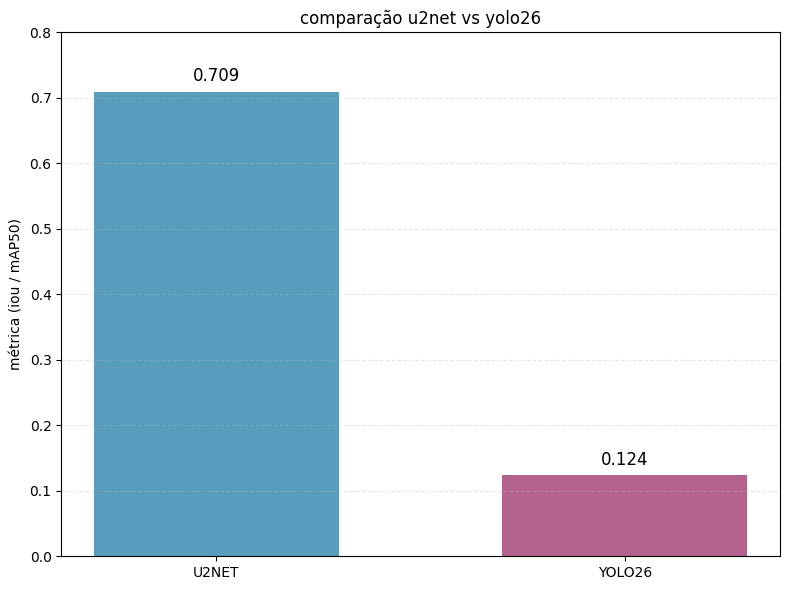

In [ ]:
#bloco 9

import matplotlib.pyplot as plt
import numpy as np

#dados
modelos = ['U2NET', 'YOLO26']
metricas = [0.7089, 0.124]  #iou vs mAP50
cores = ['#2E86AB', '#A23B72']

plt.figure(figsize=(8, 6))
barras = plt.bar(modelos, metricas, color=cores, alpha=0.8, width=0.6)

#valores em cima das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.01,
             f'{altura:.3f}', ha='center', va='bottom', fontsize=12)

plt.ylabel('métrica (iou / mAP50)')
plt.title('comparação u2net vs yolo26')
plt.ylim(0, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()